In [2]:
#this notebook mirrors beatnote analysis, but with fake data to validate that I understand the signal processing chain by injecting face modulations and extracting them


# %% Cell 1 -- Imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib widget

plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=18)

In [59]:
# %% Cell 2 -- Synthetic beat note generator
# Optics constants (same as the real analysis notebook)
WAVELENGTH = 852.34727582e-9   # m
N_BOUNCES  = 16

def f_to_v(f_hz):
    return WAVELENGTH * f_hz / N_BOUNCES      # m/s

def v_to_f(v_ms):
    return N_BOUNCES * v_ms / WAVELENGTH      # Hz

# ---- Acquisition ----
DURATION  = 10e-3     # s
FS        = 10e6       # Sa/s
F_CARRIER = 3.7625e6      # Hz

# ---- Signal levels (photodiode swings negative) ----
V_MIN = -30e-3         # V, most negative excursion
V_MAX =   0.0          # V, most positive excursion

# ---- Digitizer ----
ADC_BITS = 12
ADC_MIN  = -40e-3      # V, bottom of digitizer range
ADC_MAX  =  10e-3      # V, top of digitizer range

# ---- Slow frequency modulation: period of tens of ms ----
SLOW_FM_PERIOD = 25e-3     # s
SLOW_FM_DEV    = 10e3      # Hz, peak frequency deviation
SLOW_FM_PHASE  = 0.0       # rad

# ---- Fast frequency modulation: period of tenths of ms ----
FAST_FM_PERIOD = 1e-4    # s
FAST_FM_DEV    = 1e3       # Hz, peak frequency deviation
FAST_FM_PHASE  = 0.0       # rad

# ---- Optional amplitude modulation (fraction of full swing) ----
SLOW_AM_DEPTH = 0.0
FAST_AM_DEPTH = 0.0

# ---- Noise ----
NOISE_RMS = 1.0e-3     # V rms, white, added before quantization
SEED      = 0


def make_beat(duration=DURATION, fs=FS, f_carrier=F_CARRIER,
              v_min=V_MIN, v_max=V_MAX,
              slow_fm_period=SLOW_FM_PERIOD, slow_fm_dev=SLOW_FM_DEV,
              slow_fm_phase=SLOW_FM_PHASE,
              fast_fm_period=FAST_FM_PERIOD, fast_fm_dev=FAST_FM_DEV,
              fast_fm_phase=FAST_FM_PHASE,
              slow_am_depth=SLOW_AM_DEPTH, fast_am_depth=FAST_AM_DEPTH,
              noise_rms=NOISE_RMS,
              adc_bits=ADC_BITS, adc_min=ADC_MIN, adc_max=ADC_MAX,
              seed=SEED):
    """Return (t, v_quantized, f_true, v_ideal).

    f_true is the exact instantaneous frequency in Hz.
    v_ideal is the analog waveform before noise and quantization.
    Set a deviation or depth to 0 to disable that modulation.
    """
    n = int(round(duration * fs))
    t = np.arange(n) / fs

    f_slow = 1.0 / slow_fm_period if slow_fm_period else 0.0
    f_fast = 1.0 / fast_fm_period if fast_fm_period else 0.0

    # Instantaneous frequency
    f_true = np.full(n, float(f_carrier))
    if f_slow and slow_fm_dev:
        f_true += slow_fm_dev * np.sin(2*np.pi*f_slow*t + slow_fm_phase)
    if f_fast and fast_fm_dev:
        f_true += fast_fm_dev * np.sin(2*np.pi*f_fast*t + fast_fm_phase)

    # Phase = 2*pi * integral of f_true, done analytically so the phase is exact
    phase = 2*np.pi*f_carrier*t
    if f_slow and slow_fm_dev:
        phase += -(slow_fm_dev/f_slow) * (np.cos(2*np.pi*f_slow*t + slow_fm_phase)
                                          - np.cos(slow_fm_phase))
    if f_fast and fast_fm_dev:
        phase += -(fast_fm_dev/f_fast) * (np.cos(2*np.pi*f_fast*t + fast_fm_phase)
                                          - np.cos(fast_fm_phase))

    # Amplitude
    offset = 0.5*(v_max + v_min)
    amp    = 0.5*(v_max - v_min)
    env = np.ones(n)
    if f_slow and slow_am_depth:
        env += slow_am_depth * np.sin(2*np.pi*f_slow*t + slow_fm_phase)
    if f_fast and fast_am_depth:
        env += fast_am_depth * np.sin(2*np.pi*f_fast*t + fast_fm_phase)

    v_ideal = offset + amp * env * np.cos(phase)

    # Noise
    rng = np.random.default_rng(seed)
    v_noisy = v_ideal + rng.normal(0.0, noise_rms, n) if noise_rms else v_ideal.copy()

    # Quantize
    lsb = (adc_max - adc_min) / (2**adc_bits)
    codes = np.round((v_noisy - adc_min) / lsb)
    codes = np.clip(codes, 0, 2**adc_bits - 1)
    v_q = adc_min + codes * lsb

    return t, v_q, f_true, v_ideal


t, v, f_true, v_ideal = make_beat()

fs    = FS
xinc  = 1.0 / fs
fname = Path(f"synthetic_{F_CARRIER/1e6:.1f}MHz_"
             f"slow{SLOW_FM_DEV/1e3:.0f}kHz_fast{FAST_FM_DEV/1e3:.0f}kHz_"
             f"noise{NOISE_RMS*1e3:.1f}mV.npz")

lsb = (ADC_MAX - ADC_MIN) / (2**ADC_BITS)
n_clip = np.sum((v_ideal < ADC_MIN) | (v_ideal > ADC_MAX))

print(f"N = {len(v)},  fs = {fs/1e6:.1f} MSa/s,  duration = {len(v)*xinc*1e3:.2f} ms")
print(f"V range: {v.min()*1e3:.2f} to {v.max()*1e3:.2f} mV")
print(f"LSB = {lsb*1e6:.2f} uV,  noise = {NOISE_RMS*1e3:.2f} mV rms "
      f"({NOISE_RMS/lsb:.1f} LSB),  clipped samples = {n_clip}")
print(f"Carrier {F_CARRIER/1e6:.3f} MHz -> {f_to_v(F_CARRIER)*1e3:.3f} mm/s")
print(f"Slow FM: {1/SLOW_FM_PERIOD:.1f} Hz, dev {SLOW_FM_DEV/1e3:.2f} kHz "
      f"= {100*SLOW_FM_DEV/F_CARRIER:.3f} % = {f_to_v(SLOW_FM_DEV)*1e3:.4f} mm/s")
print(f"Fast FM: {1/FAST_FM_PERIOD/1e3:.2f} kHz, dev {FAST_FM_DEV/1e3:.2f} kHz "
      f"= {100*FAST_FM_DEV/F_CARRIER:.3f} % = {f_to_v(FAST_FM_DEV)*1e3:.4f} mm/s")
print(f"f_true range: {f_true.min()/1e6:.6f} to {f_true.max()/1e6:.6f} MHz")

N = 100000,  fs = 10.0 MSa/s,  duration = 10.00 ms
V range: -34.18 to 4.64 mV
LSB = 12.21 uV,  noise = 1.00 mV rms (81.9 LSB),  clipped samples = 0
Carrier 3.763 MHz -> 200.435 mm/s
Slow FM: 40.0 Hz, dev 10.00 kHz = 0.266 % = 0.5327 mm/s
Fast FM: 10.00 kHz, dev 1.00 kHz = 0.027 % = 0.0533 mm/s
f_true range: 3.761688 to 3.773500 MHz


Cut: 0.000 to 10.000 ms (99999 pts, 10.00 ms)


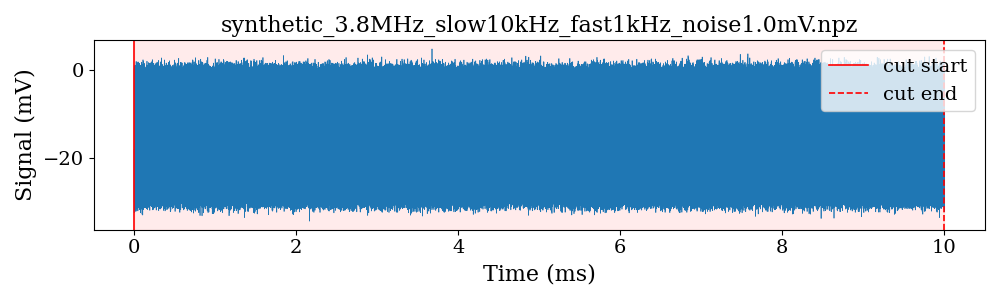

In [60]:
# %% Cell 3 -- Raw trace with cut region
t_start = 0e-3      # seconds  <-- edit
t_end   = 400e-3    # seconds  <-- edit

# Clip to available range
t_start = max(t_start, t[0])
t_end   = min(t_end, t[-1])

i_start = np.searchsorted(t, t_start)
i_end   = np.searchsorted(t, t_end)
t_cut = t[i_start:i_end]
v_cut = v[i_start:i_end]
f_true_cut = f_true[i_start:i_end]
print(f"Cut: {t_start*1e3:.3f} to {t_end*1e3:.3f} ms ({len(v_cut)} pts, {len(v_cut)*xinc*1e3:.2f} ms)")

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t * 1e3, v * 1e3, lw=0.5)
ax.axvline(t_start * 1e3, color="r", lw=1.2, label="cut start")
ax.axvline(t_end   * 1e3, color="r", lw=1.2, ls="--", label="cut end")
ax.axvspan(t_start * 1e3, t_end * 1e3, color="r", alpha=0.08)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Signal (mV)")
ax.set_title(fname.name)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

Waterfall: 9 segments x 5001 freq bins
Segment duration: 1.000 ms,  freq resolution: 1000.0 Hz


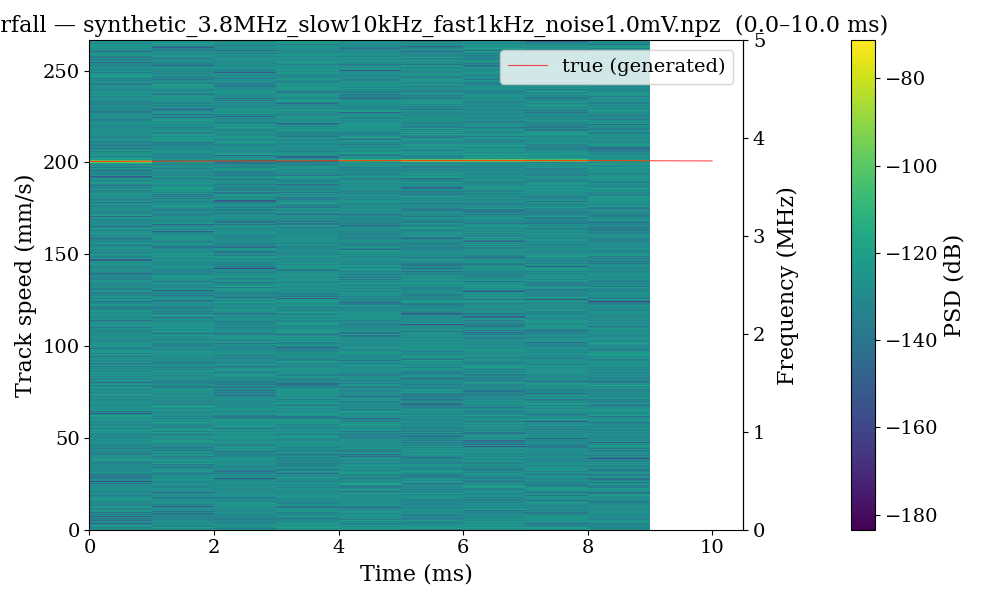

In [61]:
# %% Cell 5 — Waterfall on the cut data (time horizontal, velocity vertical)
from scipy.signal import windows          # <-- added (not imported in Cell 1)

seg_dur = 1e-3
overlap = 0
window_name = "hann"

nperseg = int(round(seg_dur / xinc))
nstep = int(round(nperseg * (1 - overlap)))
nseg = 1 + (len(v_cut) - nperseg) // nstep

if nseg < 1:
    raise ValueError(f"Cut region ({len(v_cut)*xinc*1e3:.2f} ms) shorter than segment ({seg_dur*1e3:.2f} ms)")

win = windows.get_window(window_name, nperseg)
win_norm = np.sum(win**2)

freqs = np.fft.rfftfreq(nperseg, d=xinc)
seg_times = t_cut[0] + (np.arange(nseg) * nstep + nperseg / 2) * xinc

spec = np.empty((nseg, len(freqs)), dtype=np.float32)
for i in range(nseg):
    chunk = v_cut[i*nstep : i*nstep + nperseg]
    chunk = (chunk - chunk.mean()) * win
    X = np.fft.rfft(chunk)
    psd = (np.abs(X)**2) / (fs * win_norm)
    psd[1:-1] *= 2
    spec[i] = psd

spec_db = 10 * np.log10(spec + 1e-20)
print(f"Waterfall: {nseg} segments x {len(freqs)} freq bins")
print(f"Segment duration: {seg_dur*1e3:.3f} ms,  freq resolution: {1/seg_dur:.1f} Hz")

WAVELENGTH = 852.34727582e-9   # m
N_BOUNCES  = 16                # 8 bounces, double-pass

def f_to_v(f_hz):
    return WAVELENGTH * f_hz / N_BOUNCES   # m/s

def v_to_f(v_ms):
    return N_BOUNCES * v_ms / WAVELENGTH   # Hz

# Plot with velocity (mm/s) on the primary y-axis
vels_mm = f_to_v(freqs) * 1e3   # mm/s

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(
    seg_times * 1e3,
    vels_mm,
    spec_db.T,
    shading="auto",
    cmap="viridis",
)

# Overlay the generated modulation (truth from Cell 2)   <-- added
DEC_TRUE = max(1, len(t_cut) // 20000)
ax.plot(
    t_cut[::DEC_TRUE] * 1e3,
    f_to_v(f_true_cut[::DEC_TRUE]) * 1e3,
    color="red",
    lw=0.8,
    alpha=0.7,
    label="true (generated)",
)
ax.legend(loc="upper right")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Track speed (mm/s)")
ax.set_title(f"Waterfall — {fname.name}  ({t_start*1e3:.1f}–{t_end*1e3:.1f} ms)")

# Secondary y-axis: frequency in MHz
secax = ax.secondary_yaxis(
    "right",
    functions=(
        lambda v_mm: v_to_f(v_mm * 1e-3) / 1e6,   # mm/s -> MHz
        lambda f_mhz: f_to_v(f_mhz * 1e6) * 1e3,  # MHz -> mm/s
    ),
)
secax.set_ylabel("Frequency (MHz)", labelpad=8)

# Colorbar placed with explicit padding so it sits clear of the right-side axis
cbar = fig.colorbar(im, ax=ax, label="PSD (dB)", pad=0.12)

# Optional zoom / clim
# ax.set_ylim(0, f_to_v(100e6)*1e3)
# im.set_clim(vmax=spec_db.max(), vmin=spec_db.max() - 60)
_dev = 2.0 * (SLOW_FM_DEV + FAST_FM_DEV)                       # <-- was 269.5, 270.5
#plt.ylim(f_to_v(F_CARRIER - _dev) * 1e3, f_to_v(F_CARRIER + _dev) * 1e3)

plt.tight_layout()
plt.show()
plt.grid()

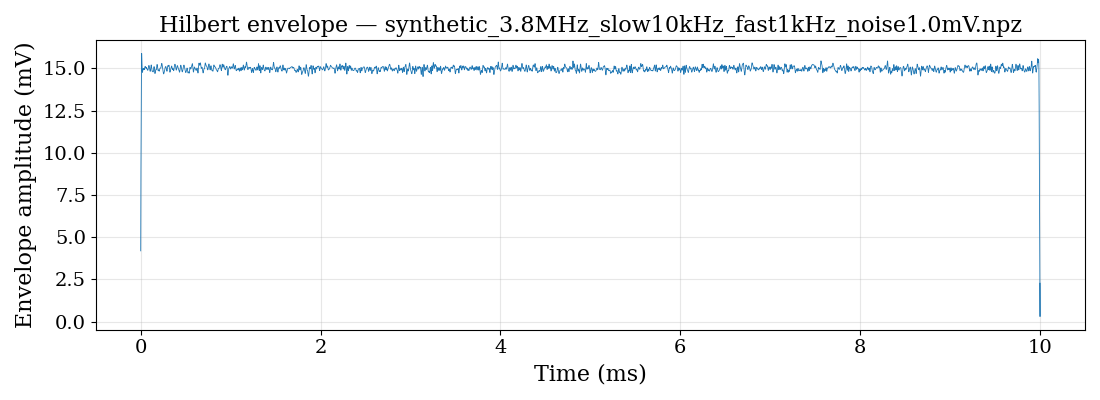

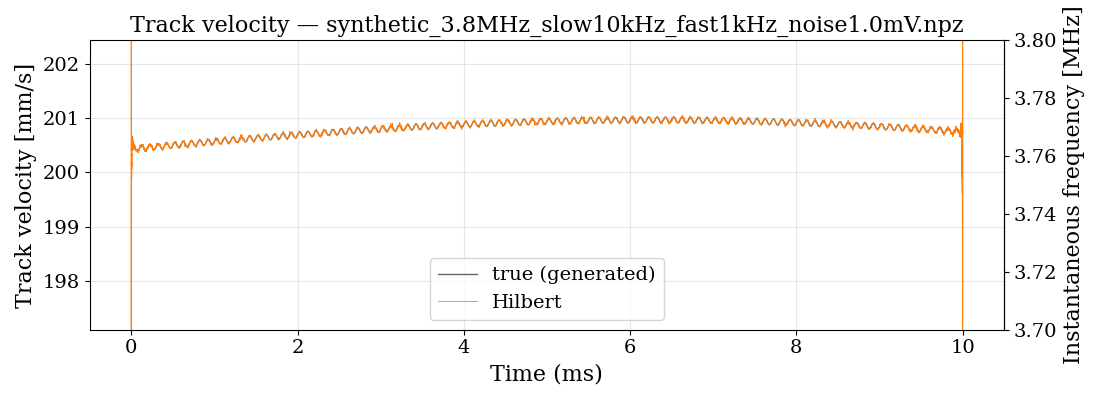

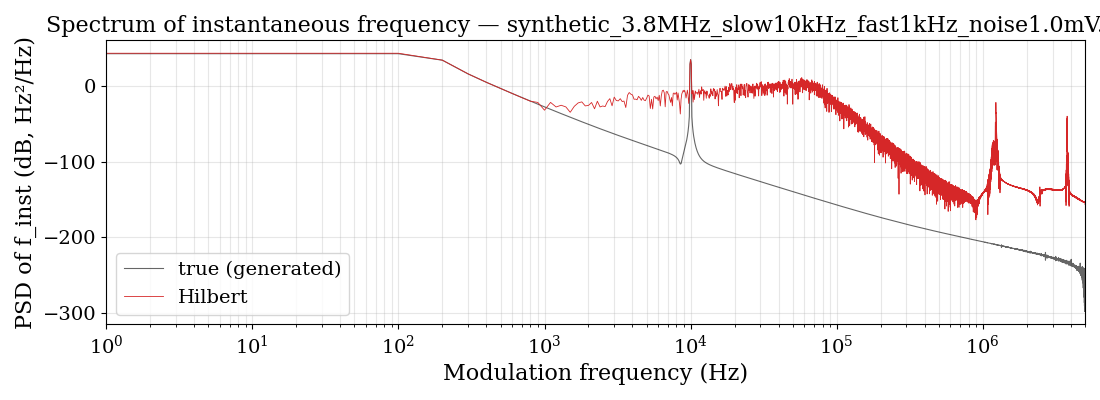

In [62]:
# %% Cell 6 — Hilbert envelope, instantaneous frequency, velocity
from scipy.signal import hilbert, butter, filtfilt
from scipy.ndimage import uniform_filter1d

# ---- Bandpass around the expected beat band ----
# Carrier is at 5 MHz. Peak deviation is SLOW_FM_DEV + FAST_FM_DEV = 12 kHz,
# so +/-50 kHz passes every sideband with room to spare.
F_LO = 3.7e6    # Hz, high-pass corner (kills DC drift / low-freq junk)
F_HI = 3.8e6    # Hz, low-pass corner
ORDER = 4

nyq = fs / 2
b, a = butter(ORDER, [F_LO/nyq, F_HI/nyq], btype="band")
v_filt = filtfilt(b, a, v_cut)

# ---- Analytic signal ----
analytic = hilbert(v_filt)
envelope = np.abs(analytic)
phase = np.unwrap(np.angle(analytic))

# Instantaneous frequency via centered difference
f_inst = np.gradient(phase, xinc) / (2 * np.pi)   # Hz

# Optional: smooth f_inst a bit (rolling mean) to suppress phase noise.
# Window of ~1 ms is usually a good starting point.
SMOOTH_MS = 0
nsmooth = max(1, int(round(SMOOTH_MS * 1e-3 * fs)))
if nsmooth > 1:
    kernel = np.ones(nsmooth) / nsmooth
    f_inst_s = uniform_filter1d(f_inst, size=nsmooth, mode="nearest")
    env_s    = uniform_filter1d(envelope, size=nsmooth, mode="nearest")
else:
    f_inst_s = f_inst
    env_s    = envelope

# ---- Velocity ----
v_track = WAVELENGTH * f_inst_s / N_BOUNCES   # m/s

# Decimate for plotting (don't try to draw 10M points)
DECIM = max(1, len(t_cut) // 100000)
ts = t_cut[::DECIM] * 1e3   # ms

# %% Figure 1 — Hilbert envelope
plt.close('all')
fig1, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(ts, env_s[::DECIM] * 1e3, lw=0.6, color="C0")
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Envelope amplitude (mV)")
ax1.set_title(f"Hilbert envelope — {fname.name}")
ax1.grid(True, alpha=0.3)
fig1.tight_layout()
plt.show()


fig2, ax2 = plt.subplots(figsize=(11, 4))
v_track_khz = f_to_v(f_inst_s) * 1e3   # m/s -> mm/s
ax2.plot(ts, f_to_v(f_true_cut[::DECIM]) * 1e3, lw=1.0, color="k",
         alpha=0.6, label="true (generated)")                      # <-- added
ax2.plot(ts, v_track_khz[::DECIM], lw=0.6, color="C1", label="Hilbert")
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Track velocity [mm/s]")
ax2.set_title(f"Track velocity — {fname.name}")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="best")                                             # <-- added
ax2.set_ylim(f_to_v(F_LO) * 1e3, f_to_v(F_HI) * 1e3)



secax = ax2.secondary_yaxis(
    "right",
    functions=(
        lambda v_mm:  v_to_f(v_mm * 1e-3) / 1e6,   # mm/s -> MHz
        lambda f_mhz: f_to_v(f_mhz * 1e6) * 1e3,   # MHz -> mm/s
    ),
)
secax.set_ylabel("Instantaneous frequency [MHz]")

fig2.tight_layout()
plt.show()


# %% Figure 4 — FFT of instantaneous frequency
# Reveals periodic structure in the velocity (mechanical resonances,
# servo oscillations, mains pickup, encoder ripple, etc.)

# Use the unsmoothed f_inst so we don't roll off real high-frequency content.
# Detrend by removing the mean (and optionally a linear trend) so the DC
# component and the overall sweep don't dominate the spectrum.
from scipy.signal import detrend

f_for_fft = detrend(f_inst, type="linear")   # remove mean + linear sweep

# Window to control spectral leakage
N = len(f_for_fft)
win = np.hanning(N)
win_norm = np.sum(win**2)

F = np.fft.rfft(f_for_fft * win)
psd = (np.abs(F) ** 2) / (fs * win_norm)
psd[1:-1] *= 2
freqs_fft = np.fft.rfftfreq(N, d=xinc)

psd_db = 10 * np.log10(psd + 1e-30)

# Same spectrum for the generated truth, for comparison            # <-- added
F_t = np.fft.rfft(detrend(f_true_cut, type="linear") * win)
psd_t = (np.abs(F_t) ** 2) / (fs * win_norm)
psd_t[1:-1] *= 2
psd_t_db = 10 * np.log10(psd_t + 1e-30)

fig4, ax4 = plt.subplots(figsize=(11, 4))
ax4.semilogx(freqs_fft, psd_t_db, lw=0.8, color="k", alpha=0.6,
             label="true (generated)")                             # <-- added
ax4.semilogx(freqs_fft, psd_db, lw=0.6, color="C3", label="Hilbert")
ax4.set_xlabel("Modulation frequency (Hz)")
ax4.set_ylabel("PSD of f_inst (dB, Hz²/Hz)")
ax4.set_title(f"Spectrum of instantaneous frequency — {fname.name}")
ax4.grid(True, which="both", alpha=0.3)
ax4.legend(loc="best")                                             # <-- added
ax4.set_xlim(1, fs/2)
fig4.tight_layout()
plt.show()